# DBGSOM vs. MiniSom vs. SuSi — Comparison

This notebook compares DBGSOM (`SomVQ`) with [justglowing/minisom](https://github.com/JustGlowing/minisom) and [felixriese/susi](https://github.com/felixriese/susi) on the scikit-learn Digits dataset.

## Algorithm Overview

| Property         | DBGSOM                                                              | MiniSom                         | SuSi                                         |
| ---------------- | ------------------------------------------------------------------- | ------------------------------- | -------------------------------------------- |
| Learning rule    | **Batch** (all samples per epoch)                                   | **Online** (sample-by-sample)   | Online or **Batch**                          |
| Grid topology    | Rectangular (grows dynamically)                                     | Rectangular / hexagonal (fixed) | Rectangular (fixed)                          |
| Growth criterion | Neuron added where accumulated error exceeds growing threshold (GT) | —                               | —                                            |
| Initialization   | 4 neurons (chosen from training samples)                            | Random or PCA                   | Random or PCA                                |
| API              | **sklearn-compatible** (`fit` / `transform` / `predict`)            | Custom API (`train` / `winner`) | **sklearn-compatible** (`fit` / `transform`) |
| Neighborhood     | Gaussian decay over epochs                                          | Gaussian decay over iterations  | Pseudo-Gaussian or Mexican Hat               |
| Distance metrics | Euclidean, Cosine                                                   | Euclidean                       | Euclidean, Manhattan, Mahalanobis, Tanimoto  |

> **Same topology, different sizing:** All three SOMs use a rectangular grid. The key difference is that DBGSOM determines the grid size dynamically: a new neuron is inserted adjacent to all neurons whose error exceeds the growing threshold GT. MiniSom and SuSi require grid dimensions to be fixed before training.

**Fair comparison:** Because DBGSOM grows dynamically, we first train DBGSOM to determine its final neuron count `N`, then configure MiniSom and SuSi with a `ceil(sqrt(N)) × floor(sqrt(N))` grid — giving all models an approximately equal neuron budget.


## Imports


In [2]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from minisom import MiniSom
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from dbgsom.SomVQ import SomVQ

## Dataset

We use the scikit-learn **Digits** dataset: 1 797 samples, 64 features (8×8 pixel images of handwritten digits 0–9).


In [3]:
X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(
    f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes"
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Dataset: 1797 samples, 64 features, 10 classes
Train: 1437  Test: 360


## Step 1 — Train DBGSOM

DBGSOM starts with 4 neurons and grows until `max_neurons` is reached or convergence is detected.


In [4]:
som_db = SomVQ(
    n_iter=500,
    lambda_=53.5,
    max_neurons=100,
    decay_function="linear",
    sigma_end=1,
    verbose=True,
    random_state=42,
)

t0 = time.perf_counter()
som_db.fit(X_train)
t_db = time.perf_counter() - t0

n_neurons_db = len(som_db.neurons_)
print(f"DBGSOM: {n_neurons_db} neurons after {t_db:.2f}s")

 25%|██▍       | 124/500 [00:00<00:02, 144.85 epochs/s]

DBGSOM: 36 neurons after 0.87s


## Step 2 — Train MiniSom

MiniSom uses a fixed rectangular grid. We choose `side = ceil(sqrt(N))` so the total neuron count is close to DBGSOM's final count.

MiniSom's `train_batch` implements the same batch update principle as DBGSOM: weights updated after all samples as a neighbourhood-weighted average. For batch SOM the learning rate is theoretically 1.0 — the weighted average formula is already self-normalising, so `learning_rate < 1` only slows convergence without theoretical justification.

In [5]:
side = math.ceil(math.sqrt(n_neurons_db))
side2 = math.floor(math.sqrt(n_neurons_db))
n_neurons_ms = side * side2

som_ms = MiniSom(
    x=side,
    y=side2,
    input_len=X_train.shape[1],
    sigma=0.2 * np.sqrt(side**2),
    learning_rate=1.0,  # batch SOM: weighted average, lr=1 is theoretically correct
    random_seed=42,
)
som_ms.pca_weights_init(X_train)

t0 = time.perf_counter()
som_ms.train_batch(X_train, num_iteration=100 * len(X_train))
t_ms = time.perf_counter() - t0

print(f"MiniSom:  {n_neurons_ms} neurons ({side}×{side2} grid) after {t_ms:.2f}s")

MiniSom:  36 neurons (6×6 grid) after 6.85s


## Step 3 — Train SuSi

SuSi (`SOMClustering`) is an sklearn-compatible SOM library supporting online and batch training with multiple distance metrics. We use the same grid dimensions as MiniSom.

> **Note on topographic error:** SuSi does not provide a built-in topographic error. It is computed here using the same Kohonen definition as MiniSom: fraction of samples whose 1st and 2nd BMU are not adjacent in the grid.


In [6]:
from susi import SOMClustering

susi_rows, susi_cols = side, side2


def rectangular_topographic_error(weights_3d, X):
    n_rows, n_cols, _ = weights_3d.shape
    weights_flat = weights_3d.reshape(-1, X.shape[1])
    errors = 0
    for x in X:
        dists = np.linalg.norm(weights_flat - x, axis=1)
        idx1, idx2 = np.argsort(dists)[:2]
        r1, c1 = divmod(idx1, n_cols)
        r2, c2 = divmod(idx2, n_cols)
        if abs(r1 - r2) > 1 or abs(c1 - c2) > 1:
            errors += 1
    return errors / len(X)


t0 = time.perf_counter()
susi_som = SOMClustering(
    n_rows=susi_rows,
    n_columns=susi_cols,
    n_iter_unsupervised=1000,
    train_mode_unsupervised="online",
    random_state=42,
)
susi_som.fit(X_train)
t_susi = time.perf_counter() - t0

n_neurons_susi = susi_rows * susi_cols
print(
    f"SuSi:     {n_neurons_susi} neurons ({susi_rows}×{susi_cols} grid) after {t_susi:.2f}s"
)

SuSi:     36 neurons (6×6 grid) after 0.15s


## Step 4 — Train KMeans (Reference Lower Bound)

KMeans minimises quantization error by definition (Lloyd's algorithm), making it a lower bound on QE for any SOM with the same number of centroids. It has no topographic structure.

In [7]:
t0 = time.perf_counter()
km = KMeans(n_clusters=n_neurons_db, n_init=10, random_state=42)
km.fit(X_train)
t_km = time.perf_counter() - t0
print(f"KMeans:  {n_neurons_db} centroids after {t_km:.2f}s")

Exception in thread Thread-7 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Sandro\AppData\Roaming\uv\python\cpython-3.14-windows-x86_64-none\Lib\threading.py", line 1082, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "C:\Users\Sandro\AppData\Roaming\uv\python\cpython-3.14-windows-x86_64-none\Lib\threading.py", line 1024, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Sandro\AppData\Roaming\uv\python\cpython-3.14-windows-x86_64-none\Lib\subprocess.py", line 1614, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Users\Sandro\AppData\Roaming\uv\python\cpython-3.14-windows-x86_64-none\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8

KMeans:  36 centroids after 1.79s


## Step 4 — Metrics Comparison

> **Note on topographic error definitions:**
>
> All three libraries use the Kohonen definition (fraction of samples whose 1st and 2nd BMU are not adjacent), but "adjacent" differs:
>
> | Library | Neighbourhood | Definition |
> |---------|--------------|------------|
> | **DBGSOM** | **8-neighbourhood** | Chebyshev distance between BMU coordinates ≤ 1 — diagonals count as adjacent (Villmann 1997) |
> | **MiniSom** | **4-neighbourhood** | Built-in `topographic_error()` — only up/down/left/right count as adjacent |
> | **SuSi** | **8-neighbourhood** | Custom function here uses `abs(Δrow) > 1 or abs(Δcol) > 1` — diagonals count as adjacent |
>
> MiniSom's 4-neighbourhood is stricter: a diagonal neighbour that DBGSOM or SuSi accept as adjacent is flagged as an error by MiniSom. **Direct numerical comparison of DBGSOM/SuSi TE with MiniSom TE is therefore misleading.** DBGSOM and SuSi use the same adjacency definition and are directly comparable.
>
> The Chebyshev (8-neighbourhood) definition follows Villmann et al. (1997): on a rectangular grid, diagonal Voronoi cells share a boundary point, so their BMUs are topologically adjacent in the weak neighbourhood topology induced by the maximum norm.

In [8]:
qe_db = som_db.calculate_quantization_error(X_test)
qe_ms = som_ms.quantization_error(X_test)
qe_susi = susi_som.get_quantization_error()
qe_km = np.mean(np.min(euclidean_distances(X_test, km.cluster_centers_), axis=1))

te_db = som_db.topographic_error_
te_ms = som_ms.topographic_error(X_test)
te_susi = rectangular_topographic_error(susi_som.unsuper_som_, X_test)

metrics = pd.DataFrame(
    {
        "Metric": [
            "Training time (s)",
            "Neuron count",
            "Quantization error (test)",
            "Topographic error (train)",
        ],
        "DBGSOM": [
            f"{t_db:.2f}",
            n_neurons_db,
            f"{qe_db:.4f}",
            f"{te_db:.4f}",
        ],
        "MiniSom": [
            f"{t_ms:.2f}",
            n_neurons_ms,
            f"{qe_ms:.4f}",
            f"{te_ms:.4f}",
        ],
        "SuSi": [
            f"{t_susi:.2f}",
            n_neurons_susi,
            f"{qe_susi:.4f}",
            f"{te_susi:.4f}",
        ],
        "KMeans (ref)": [
            f"{t_km:.2f}",
            n_neurons_db,
            f"{qe_km:.4f}",
            "—",
        ],
    }
).set_index("Metric")

metrics

,DBGSOM,MiniSom,SuSi,KMeans (ref)
Metric,,,,
Training time (s),0.87,6.85,0.15,1.79
Neuron count,36,36,36,36
Quantization error (test),5.6063,5.4183,5.8622,4.9454
Topographic error (train),0.0244,0.4306,0.0139,—


## Step 5 — Visualization

All three SOMs are projected into the same 2D PCA space (PCA fitted on the data `X`), so neuron positions are directly comparable. Color encodes the mean distance to neighboring neurons (normalized to [0, 1]) — equivalent to a U-Matrix, darker = larger inter-neuron distances = cluster boundary.


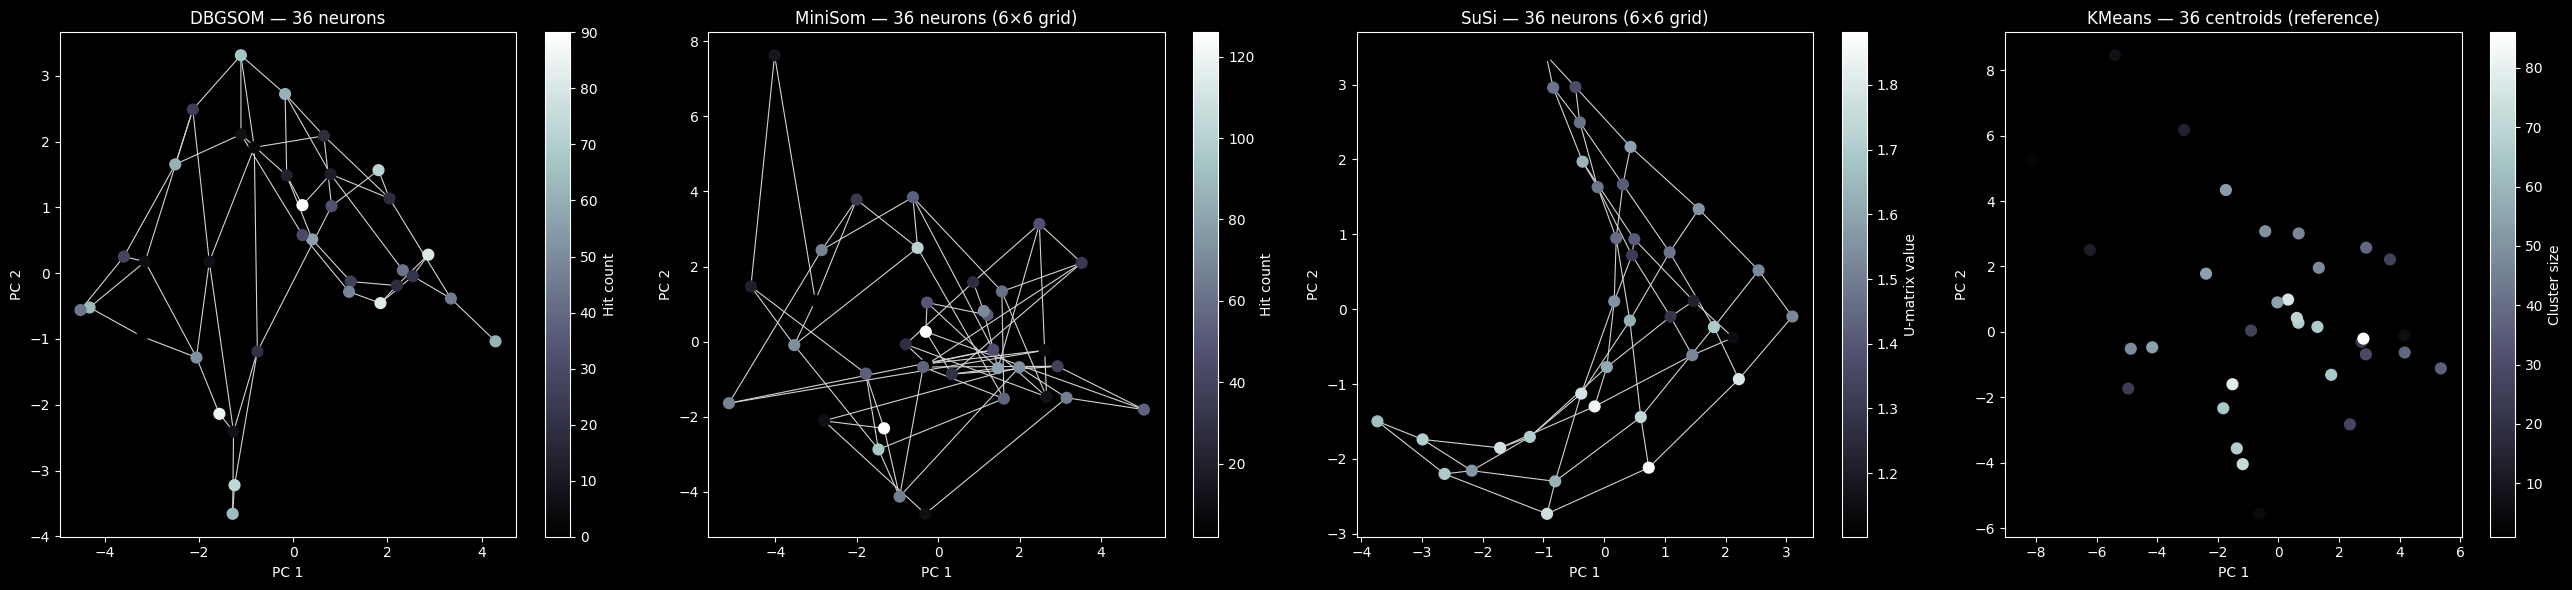

In [9]:
from sklearn.decomposition import PCA

# Fit PCA on the data so all SOMs share the same coordinate system
pca = PCA(n_components=2, random_state=42)
pca.fit(X)

fig, axes = plt.subplots(1, 4, figsize=(26, 6))

# --- DBGSOM ---
weights_db_2d = pca.transform(som_db.weights_)
avg_dist = np.array(
    [som_db.som_.nodes[n].get("hit_count", 0.0) for n in som_db.neurons_]
)
avg_dist_norm = avg_dist

ax = axes[0]
ax.set_title(f"DBGSOM — {n_neurons_db} neurons", fontsize=12)

node_pos = dict(zip(som_db.neurons_, weights_db_2d))
for u, v in som_db.som_.edges():
    x0, y0 = node_pos[u]
    x1, y1 = node_pos[v]
    ax.plot([x0, x1], [y0, y1], color="lightgray", linewidth=0.8, zorder=1)

sc = ax.scatter(
    weights_db_2d[:, 0],
    weights_db_2d[:, 1],
    c=avg_dist_norm,
    cmap="bone",
    s=60,
    zorder=2,
)
plt.colorbar(sc, ax=ax, label="Hit count")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

# --- MiniSom ---
ms_weights = som_ms.get_weights()  # shape: (side, side2, n_features)
ms_weights_flat = ms_weights.reshape(-1, X.shape[1])
weights_ms_2d = pca.transform(ms_weights_flat)

umatrix = som_ms.activation_response(X)
umatrix_flat = umatrix.reshape(-1)

ax = axes[1]
ax.set_title(f"MiniSom — {n_neurons_ms} neurons ({side}×{side2} grid)", fontsize=12)

for i in range(side):
    for j in range(side2):
        idx = i * side2 + j
        if i + 1 < side:
            nb = (i + 1) * side2 + j
            ax.plot(
                [weights_ms_2d[idx, 0], weights_ms_2d[nb, 0]],
                [weights_ms_2d[idx, 1], weights_ms_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )
        if j + 1 < side2:
            nb = i * side2 + (j + 1)
            ax.plot(
                [weights_ms_2d[idx, 0], weights_ms_2d[nb, 0]],
                [weights_ms_2d[idx, 1], weights_ms_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )

sc = ax.scatter(
    weights_ms_2d[:, 0],
    weights_ms_2d[:, 1],
    c=umatrix_flat,
    cmap="bone",
    s=60,
    zorder=2,
)
plt.colorbar(sc, ax=ax, label="Hit count")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

# --- SuSi ---
susi_weights_flat = susi_som.unsuper_som_.reshape(-1, X.shape[1])
weights_susi_2d = pca.transform(susi_weights_flat)

susi_umatrix = susi_som.get_u_matrix()[::2, ::2].reshape(-1)

ax = axes[2]
ax.set_title(
    f"SuSi — {n_neurons_susi} neurons ({susi_rows}×{susi_cols} grid)", fontsize=12
)

for i in range(susi_rows):
    for j in range(susi_cols):
        idx = i * susi_cols + j
        if i + 1 < susi_rows:
            nb = (i + 1) * susi_cols + j
            ax.plot(
                [weights_susi_2d[idx, 0], weights_susi_2d[nb, 0]],
                [weights_susi_2d[idx, 1], weights_susi_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )
        if j + 1 < susi_cols:
            nb = i * susi_cols + (j + 1)
            ax.plot(
                [weights_susi_2d[idx, 0], weights_susi_2d[nb, 0]],
                [weights_susi_2d[idx, 1], weights_susi_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )

sc = ax.scatter(
    weights_susi_2d[:, 0],
    weights_susi_2d[:, 1],
    c=susi_umatrix,
    cmap="bone",
    s=60,
    zorder=2,
)
plt.colorbar(sc, ax=ax, label="U-matrix value")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

# --- KMeans ---
km_centroids_2d = pca.transform(km.cluster_centers_)
km_counts = np.bincount(km.labels_, minlength=n_neurons_db)

ax = axes[3]
ax.set_title(f"KMeans — {n_neurons_db} centroids (reference)", fontsize=12)
sc = ax.scatter(
    km_centroids_2d[:, 0],
    km_centroids_2d[:, 1],
    c=km_counts,
    cmap="bone",
    s=60,
)
plt.colorbar(sc, ax=ax, label="Cluster size")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

plt.tight_layout()
plt.show()

## Summary

| Aspect                    | DBGSOM                                     | MiniSom                                            | SuSi                                         | KMeans                    |
| ------------------------- | ------------------------------------------ | -------------------------------------------------- | -------------------------------------------- | ------------------------- |
| **Best for**              | Unknown optimal map size; automatic sizing | Quick experiments; well-understood grid size       | sklearn pipelines; multiple distance metrics | QE lower bound reference  |
| **Hyperparameter burden** | `lambda_`, `max_neurons`                   | Grid dimensions `x`, `y`, `learning_rate`, `sigma` | Grid dimensions, `n_iter_unsupervised`       | `n_clusters`              |
| **sklearn pipelines**     | Yes (`fit` / `transform` / `predict`)      | No (custom API)                                    | Yes (`fit` / `transform`)                    | Yes                       |
| **Growing overhead**      | Yes (error tracking + insertion per epoch) | No                                                 | No                                           | No                        |
| **Grid topology**         | Rectangular, size determined automatically | Rectangular / hexagonal, fixed upfront             | Rectangular, fixed upfront                   | None                      |
| **Topographic structure** | Yes                                        | Yes                                                | Yes                                          | No                        |
| **Distance metrics**      | Euclidean, Cosine                          | Euclidean                                          | Euclidean, Manhattan, Mahalanobis, Tanimoto  | Euclidean                 |
| **TE neighbourhood**      | **8-neighbourhood** (Chebyshev, Villmann)  | **4-neighbourhood** (stricter)                     | **8-neighbourhood** (more lenient)           | N/A                       |
| **Maintained (2025)**     | ✓                                          | ✓ (bug fixes only)                                 | ✓                                            | ✓ (sklearn)               |

DBGSOM trades off a slightly higher training cost for the ability to adapt the map size automatically, which is beneficial when the ideal number of neurons is not known in advance. SuSi offers the broadest choice of distance metrics and full sklearn compatibility with a fixed grid.

**KMeans as reference:** KMeans (with the same centroid count) represents the minimum achievable QE for a given number of prototypes — any SOM will have equal or higher QE due to the topographic neighbourhood constraint. The gap between SOM QE and KMeans QE quantifies the cost of preserving topology.

> **Topographic error caveat:** DBGSOM uses an 8-neighbourhood (Chebyshev distance ≤ 1, diagonals included) following Villmann et al. (1997). MiniSom uses a stricter 4-neighbourhood (Manhattan distance ≤ 1). SuSi TE computed here also uses 8-neighbourhood. DBGSOM and SuSi TE values are directly comparable; MiniSom TE values are structurally higher due to the stricter definition.

---

## Scaling Test — Fashion-MNIST

To stress-test scaling behaviour we use a 10 000-sample subset of Fashion-MNIST (784 features, 10 classes) — roughly 5.6× more samples and 12× more features than Digits.

Training budgets are scaled proportionally:

- **DBGSOM**: same epoch count (`n_iter=300`), `max_neurons=100`
- **MiniSom**: `num_iteration = 50 × N` (reduced from 300× to keep runtime tractable)
- **SuSi**: `n_iter_unsupervised = 50 000` (~5× passes over all samples)

> **SuSi note:** In online mode each iteration draws _one_ random sample, independent of N. To expose the SOM to all data ~5 times we set `n_iter = 5 × N`. This is the key scaling difference from DBGSOM and MiniSom.


In [10]:
from sklearn.datasets import fetch_openml

n_samples = 20_000
fmnist = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X_all = StandardScaler().fit_transform(fmnist.data[:n_samples].astype(float))
y_all = fmnist.target[:n_samples]

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(
    f"Dataset: {X_all.shape[0]} samples, {X_all.shape[1]} features, {len(np.unique(y_all))} classes"
)
print(f"Train: {len(X_train_l)}  Test: {len(X_test_l)}")

Dataset: 20000 samples, 784 features, 10 classes
Train: 16000  Test: 4000


In [16]:
som_db_l = SomVQ(
    n_iter=1000,
    lambda_=100,
    max_neurons=500,
    neighborhood_function="cutgauss",
    verbose=True,
    sigma_end=1.5,
    sigma_fine=0.5,
    random_state=42,
)
t0 = time.perf_counter()
som_db_l.fit(X_train_l)
t_db_l = time.perf_counter() - t0
n_neurons_db_l = len(som_db_l.neurons_)
print(f"DBGSOM:  {n_neurons_db_l} neurons after {t_db_l:.2f}s")

side_l = math.ceil(math.sqrt(n_neurons_db_l))
side2_l = math.floor(math.sqrt(n_neurons_db_l))
n_neurons_ms_l = side_l * side2_l

som_ms_l = MiniSom(
    x=side_l,
    y=side2_l,
    input_len=X_train_l.shape[1],
    sigma=0.2 * np.sqrt(side_l**2),
    learning_rate=1.0,  # batch SOM: weighted average, lr=1 is theoretically correct
    random_seed=42,
)
som_ms_l.pca_weights_init(X_train_l)
t0 = time.perf_counter()
som_ms_l.train_batch(X_train_l, num_iteration=1 * len(X_train_l))
t_ms_l = time.perf_counter() - t0
print(f"MiniSom: {n_neurons_ms_l} neurons ({side_l}×{side2_l}) after {t_ms_l:.2f}s")

susi_rows_l, susi_cols_l = side_l, side2_l
susi_som_l = SOMClustering(
    n_rows=susi_rows_l,
    n_columns=susi_cols_l,
    n_iter_unsupervised=1 * len(X_train_l),
    train_mode_unsupervised="online",
    random_state=42,
)
t0 = time.perf_counter()
susi_som_l.fit(X_train_l)
t_susi_l = time.perf_counter() - t0
n_neurons_susi_l = susi_rows_l * susi_cols_l
print(
    f"SuSi:    {n_neurons_susi_l} neurons ({susi_rows_l}×{susi_cols_l}) after {t_susi_l:.2f}s"
)

 53%|█████▎    | 526/1000 [00:27<00:24, 19.14 epochs/s]


DBGSOM:  265 neurons after 28.16s
MiniSom: 272 neurons (17×16) after 29.45s
SuSi:    272 neurons (17×16) after 58.00s


In [17]:
t0 = time.perf_counter()
km_l = KMeans(n_clusters=n_neurons_db_l, random_state=42)
km_l.fit(X_train_l)
t_km_l = time.perf_counter() - t0
print(f"KMeans:  {n_neurons_db_l} centroids after {t_km_l:.2f}s")

KMeans:  265 centroids after 14.16s


In [18]:
qe_db_l = som_db_l.calculate_quantization_error(X_test_l)
qe_ms_l = som_ms_l.quantization_error(X_test_l)
qe_susi_l = susi_som_l.get_quantization_error()
qe_km_l = np.mean(np.min(euclidean_distances(X_test_l, km_l.cluster_centers_), axis=1))

te_db_l = som_db_l.topographic_error_
te_ms_l = som_ms_l.topographic_error(X_test_l)
te_susi_l = rectangular_topographic_error(susi_som_l.unsuper_som_, X_test_l)

pd.DataFrame(
    {
        "Metric": [
            "Training time (s)",
            "Neuron count",
            "Quantization error (test)",
            "Topographic error (train)",
        ],
        "DBGSOM": [
            f"{t_db_l:.2f}",
            n_neurons_db_l,
            f"{qe_db_l:.4f}",
            f"{te_db_l:.4f}",
        ],
        "MiniSom": [
            f"{t_ms_l:.2f}",
            n_neurons_ms_l,
            f"{qe_ms_l:.4f}",
            f"{te_ms_l:.4f}",
        ],
        "SuSi": [
            f"{t_susi_l:.2f}",
            n_neurons_susi_l,
            f"{qe_susi_l:.4f}",
            f"{te_susi_l:.4f}",
        ],
        "KMeans (ref)": [
            f"{t_km_l:.2f}",
            n_neurons_db_l,
            f"{qe_km_l:.4f}",
            "—",
        ],
    }
).set_index("Metric")

,DBGSOM,MiniSom,SuSi,KMeans (ref)
Metric,,,,
Training time (s),28.16,29.45,58.00,14.16
Neuron count,265,272,272,265
Quantization error (test),15.0831,16.9722,16.8176,14.8036
Topographic error (train),0.2048,0.0612,0.0168,—


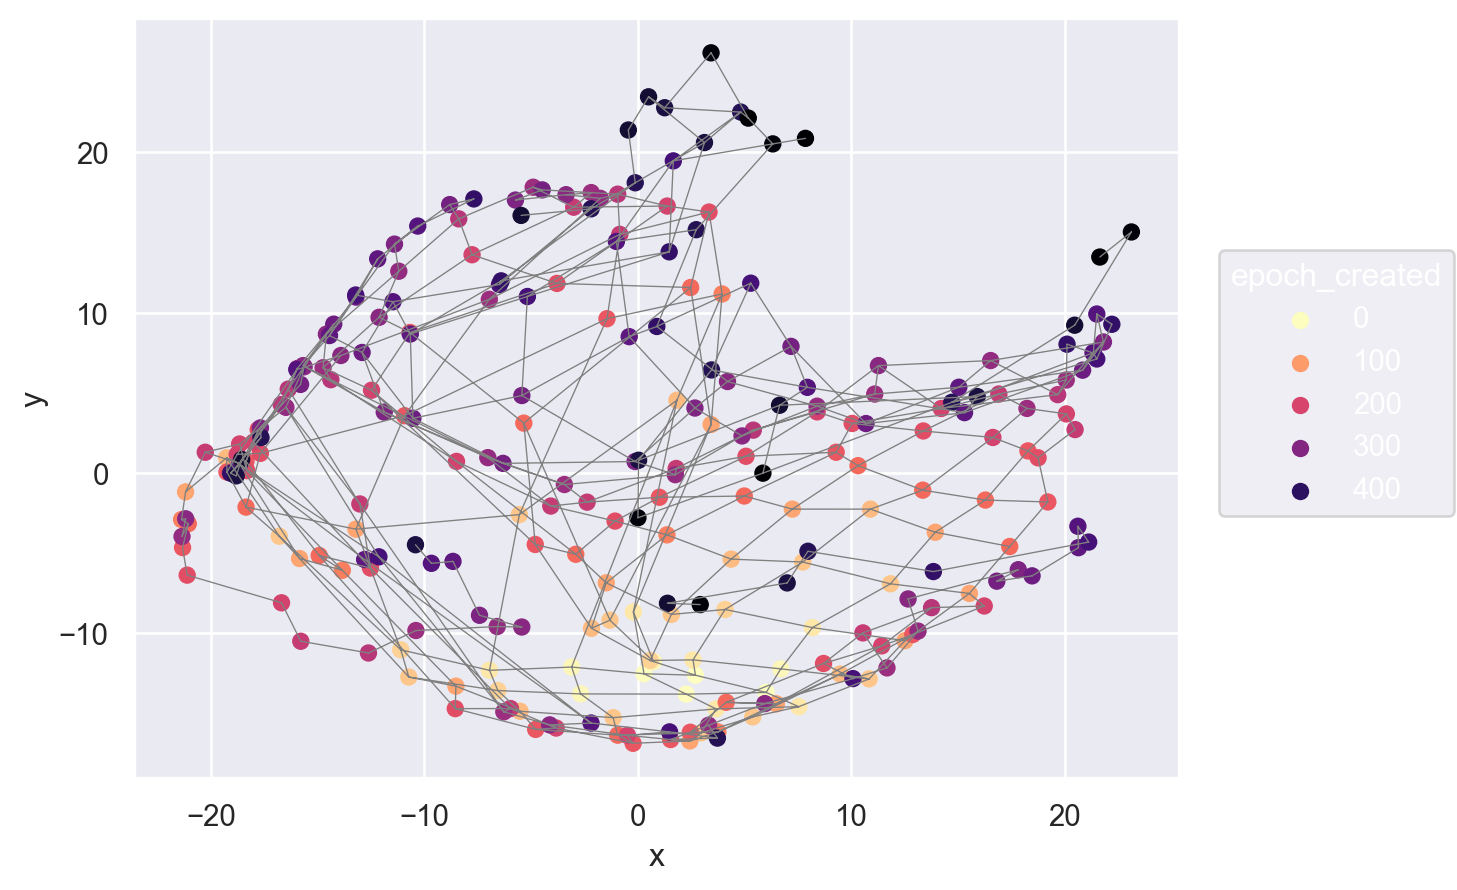

In [19]:
som_db_l.plot(color="epoch_created", layout="pca", X=X_test_l)

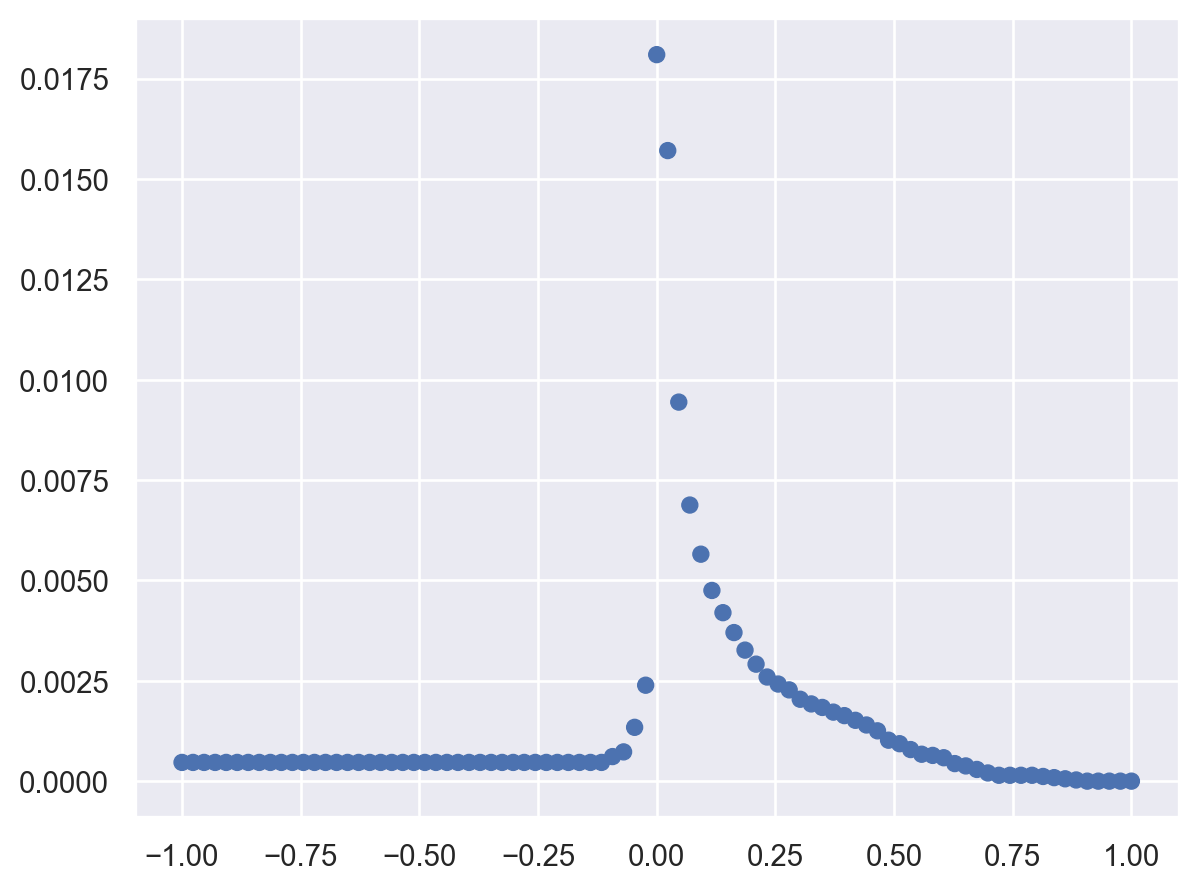

In [20]:
import seaborn.objects as so

so.Plot(
    x=som_db_l.topographic_function(X_test_l)[1],
    y=som_db_l.topographic_function(X_test_l)[0],
).add(so.Dot())